# Laboratorio 3
## Sebastian Huertas 22295
## Sofia Velasquez 22049

In [15]:
import os
import itertools
import pefile
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MultiLabelBinarizer

In [16]:
def extraer_features_pe(fullpath):
    features = {
        'archivo': os.path.basename(fullpath),
        'path': fullpath,
        'empaquetado': False,
        'razon_packing': 'No empaquetado',
        'num_secciones': 0,
        'imports': [],
        'dlls': [],
        'entropia_promedio': 0.0,
        'tam_code': 0,
        'tam_data': 0,
        'num_exports': 0,
        'subsistema': '',
        'arquitectura': ''
    }

    PACKER_SECTIONS = {b'UPX0', b'UPX1', b'UPX2', b'.packed', b'PECompact'}

    try:
        pe = pefile.PE(fullpath)

        features['num_secciones'] = len(pe.sections)
        features['tam_code'] = pe.OPTIONAL_HEADER.SizeOfCode
        features['tam_data'] = pe.OPTIONAL_HEADER.SizeOfInitializedData
        features['subsistema'] = str(pe.OPTIONAL_HEADER.Subsystem)
        features['arquitectura'] = hex(pe.FILE_HEADER.Machine)

        entropias = []
        for section in pe.sections:
            name = section.Name.rstrip(b'\x00')
            if name in PACKER_SECTIONS:
                features['empaquetado'] = True
                features['razon_packing'] = f'Seccion packer: {name.decode(errors="ignore")}'
            e = section.get_entropy()
            entropias.append(e)
            if e > 7.0 and not features['empaquetado']:
                features['empaquetado'] = True
                features['razon_packing'] = f'Alta entropia ({e:.2f}) en {name.decode(errors="ignore")}'

        features['entropia_promedio'] = round(np.mean(entropias), 4) if entropias else 0.0

        if hasattr(pe, 'DIRECTORY_ENTRY_IMPORT'):
            for entry in pe.DIRECTORY_ENTRY_IMPORT:
                dll = entry.dll.decode('utf-8', errors='ignore')
                features['dlls'].append(dll)
                for imp in entry.imports:
                    if imp.name:
                        features['imports'].append(imp.name.decode('utf-8', errors='ignore'))

        if hasattr(pe, 'DIRECTORY_ENTRY_EXPORT'):
            features['num_exports'] = len(pe.DIRECTORY_ENTRY_EXPORT.symbols)

    except Exception as e:
        print(f"  Error en {os.path.basename(fullpath)}: {e}")

    return features

In [17]:
def is_pe(fullpath):
    try:
        with open(fullpath, 'rb') as f:
            return f.read(2) == b'MZ'
    except:
        return False

DATASET_PATH = "C:/Users/thiag/Desktop/MALWR_lab3/MALWR"  # Agregar en donde lo tienes

registros = []

for root, dirs, files in os.walk(DATASET_PATH):
    for fname in files:
        fpath = os.path.join(root, fname)
        if not is_pe(fpath):
            print(f"Omitido (no PE): {fname}")
            continue
        print(f"Procesando: {fname}")
        features = extraer_features_pe(fpath)
        registros.append(features)

df_raw = pd.DataFrame(registros)
print(f"\nTotal ejecutables procesados: {len(df_raw)}")
df_raw.head()

Omitido (no PE): .DS_Store
Procesando: 1F2EB7B090018D975E6D9B40868C94CA
Procesando: 33DE5067A433A6EC5C328067DC18EC37
Procesando: 65018CD542145A3792BA09985734C12A
Procesando: 650A6FCA433EE243391E4B4C11F09438
Procesando: 6FAA4740F99408D4D2DDDD0B09BBDEFD
Procesando: 785003A405BC7A4EBCBB21DDB757BF3F
Procesando: 8442AE37B91F279A9F06DE4C60B286A3
Procesando: 99A39866A657A10949FCB6D634BB30D5
Procesando: A316D5AECA269CA865077E7FFF356E7D
Procesando: AAAz2E1B6940985A23E5639450F8391820655
Procesando: AL65_DB05DF0498B59B42A8E493CF3C10C578
Procesando: B07322743778B5868475DBE66EEDAC4F
Procesando: B98hX8E8622C393D7E832D39E620EAD5D3B49
Procesando: BVJ2D9FBF759F527AF373E34673DC3ACA462
Procesando: DS22_A670D13D4D014169C4080328B8FEB86
Procesando: EEE99EC8AA67B05407C01094184C33D2B5A44
Procesando: F6655E39465C2FF5B016980D918EA028
Procesando: F8437E44748D2C3FCF84019766F4E6DC
Procesando: FGJKJJ1_2BA0D0083976A5C1E3315413CDCFFCD2
Procesando: FGTR43_EF8E0FB20E7228C7492CCDC59D87C690
Procesando: FHHH6576C196385407

,archivo,path,empaquetado,razon_packing,num_secciones,imports,dlls,entropia_promedio,tam_code,tam_data,num_exports,subsistema,arquitectura
0,1F2EB7B090018D975E6D9B40868C94CA,C:/Users/thiag/Desktop/MALWR_lab3/MALWR\1F2EB7...,True,Seccion packer: UPX1,3,"[LoadLibraryA, ExitProcess, GetProcAddress, Vi...","[KERNEL32.DLL, MSVCRT.dll, USER32.dll, WS2_32....",3.3796,4096,4096,0,2,0x14c
1,33DE5067A433A6EC5C328067DC18EC37,C:/Users/thiag/Desktop/MALWR_lab3/MALWR\33DE50...,True,Seccion packer: UPX1,3,"[LoadLibraryA, ExitProcess, GetProcAddress, Vi...","[KERNEL32.DLL, MSVCRT.dll, SHELL32.dll, USER32...",3.5070,4096,4096,0,2,0x14c
2,65018CD542145A3792BA09985734C12A,C:/Users/thiag/Desktop/MALWR_lab3/MALWR\65018C...,True,Seccion packer: UPX1,3,"[LoadLibraryA, ExitProcess, GetProcAddress, Vi...","[KERNEL32.DLL, MSVCRT.dll, SHELL32.dll, USER32...",3.5065,4096,4096,0,2,0x14c
3,650A6FCA433EE243391E4B4C11F09438,C:/Users/thiag/Desktop/MALWR_lab3/MALWR\650A6F...,True,Seccion packer: UPX1,3,"[LoadLibraryA, ExitProcess, GetProcAddress, Vi...","[KERNEL32.DLL, MSVCRT.dll, SHELL32.dll, USER32...",3.5082,4096,4096,0,2,0x14c
4,6FAA4740F99408D4D2DDDD0B09BBDEFD,C:/Users/thiag/Desktop/MALWR_lab3/MALWR\6FAA47...,True,Seccion packer: UPX1,3,"[LoadLibraryA, ExitProcess, GetProcAddress, Vi...","[KERNEL32.DLL, MSVCRT.dll, SHELL32.dll, USER32...",3.5089,4096,4096,0,2,0x14c


## Exploracion de datos

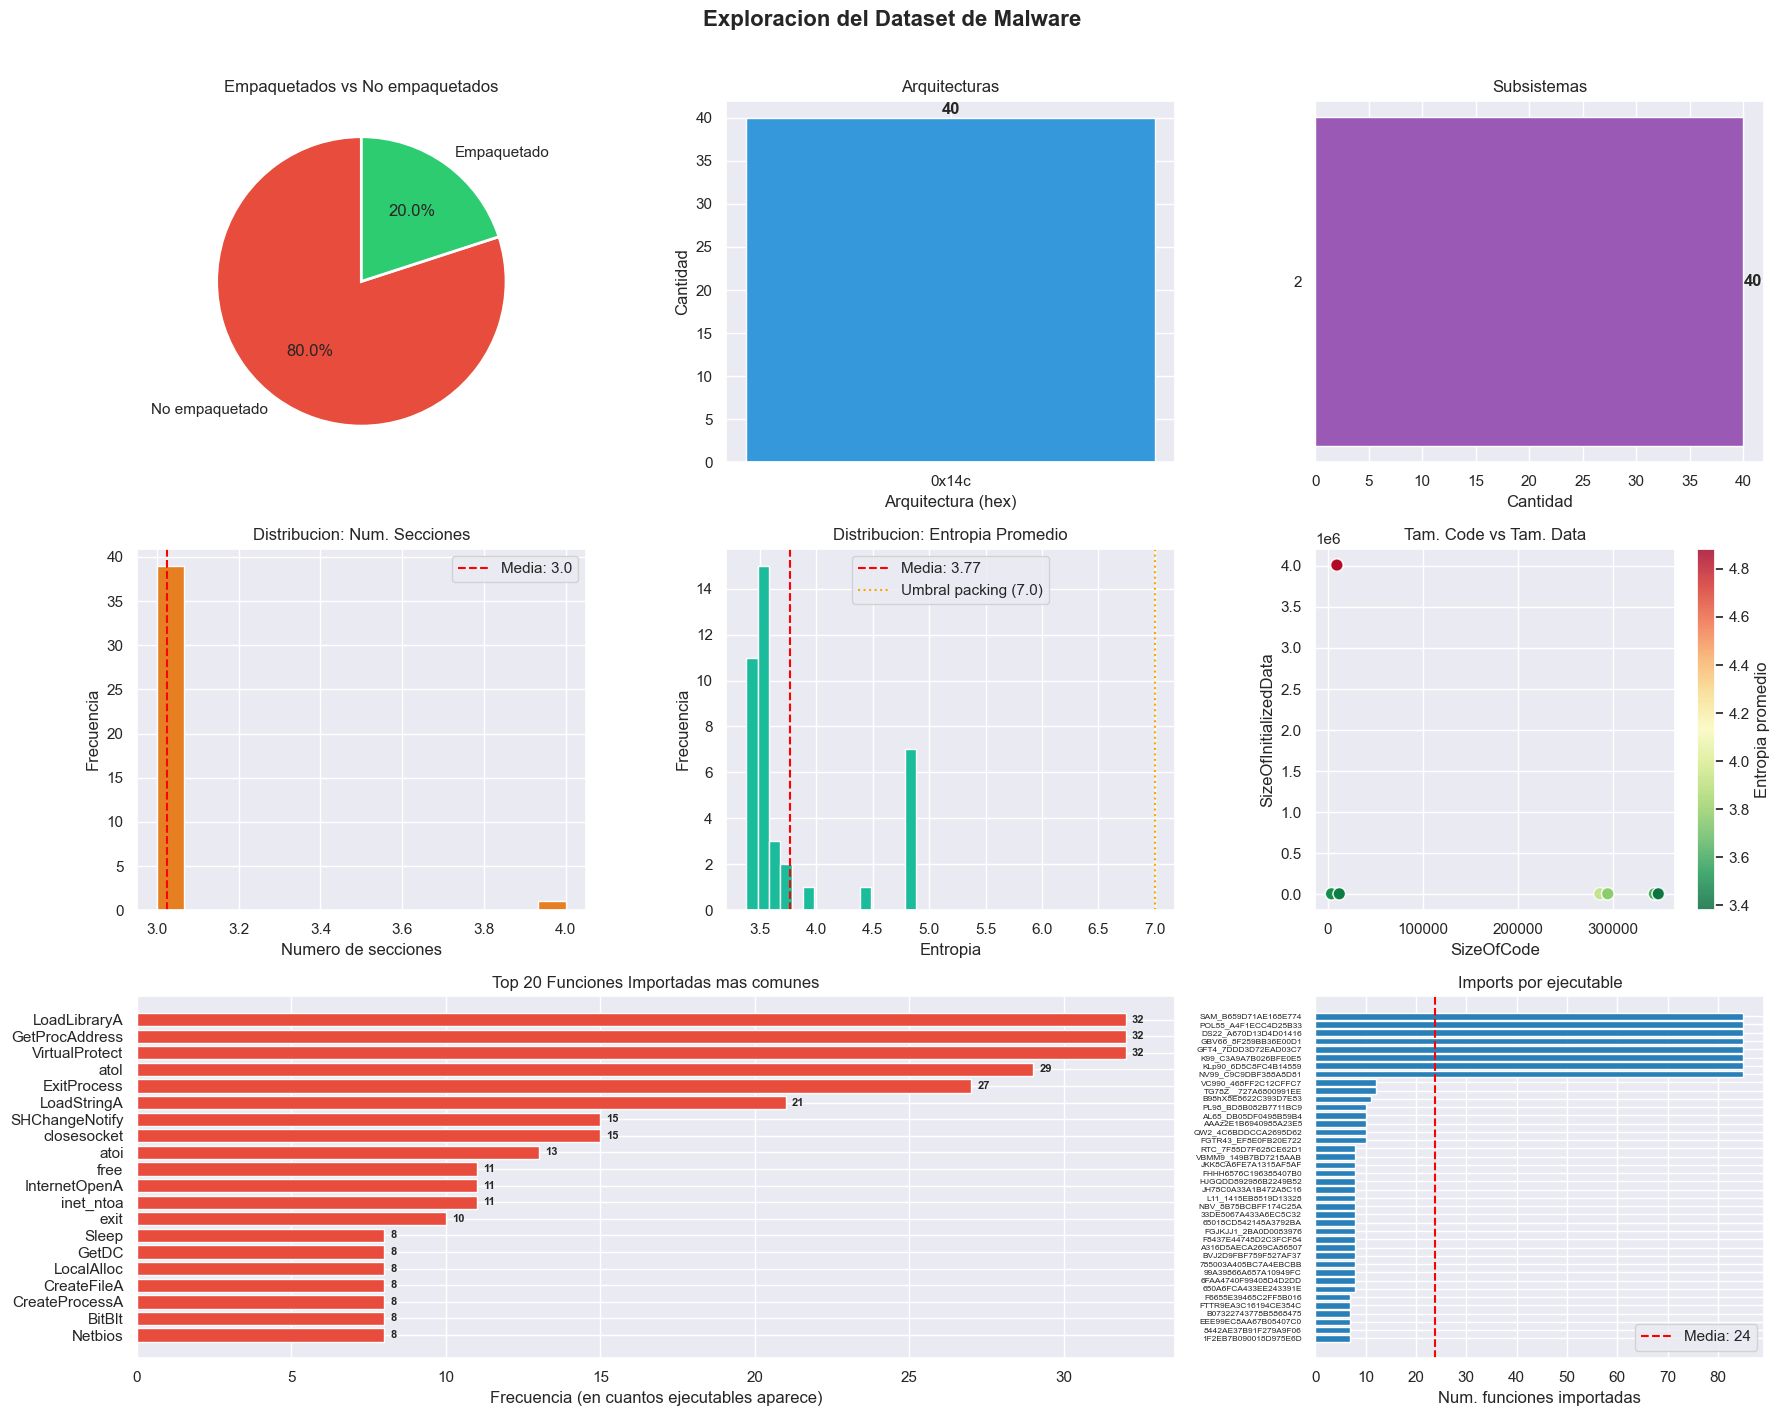

In [18]:
sns.set_theme(style="darkgrid")
fig = plt.figure(figsize=(18, 14))
gs = gridspec.GridSpec(3, 3, figure=fig)
fig.suptitle("Exploracion del Dataset de Malware", fontsize=16, fontweight='bold', y=1.01)

# empaquetados vs no empaquetados
ax1 = fig.add_subplot(gs[0, 0])
pack_counts = df_raw['empaquetado'].value_counts()
colors = ['#e74c3c', '#2ecc71']
ax1.pie(pack_counts, labels=['No empaquetado', 'Empaquetado'], autopct='%1.1f%%',
        colors=colors, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax1.set_title("Empaquetados vs No empaquetados")

# arquitecturas
ax2 = fig.add_subplot(gs[0, 1])
arch_counts = df_raw['arquitectura'].value_counts()
bars = ax2.bar(arch_counts.index, arch_counts.values, color='#3498db', edgecolor='white')
for bar, val in zip(bars, arch_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             str(val), ha='center', va='bottom', fontweight='bold')
ax2.set_title("Arquitecturas")
ax2.set_xlabel("Arquitectura (hex)")
ax2.set_ylabel("Cantidad")

# subsistemas
ax3 = fig.add_subplot(gs[0, 2])
sub_counts = df_raw['subsistema'].value_counts()
ax3.barh(sub_counts.index.astype(str), sub_counts.values, color='#9b59b6', edgecolor='white')
for i, val in enumerate(sub_counts.values):
    ax3.text(val + 0.1, i, str(val), va='center', fontweight='bold')
ax3.set_title("Subsistemas")
ax3.set_xlabel("Cantidad")

# -distribucion numero de secciones
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(df_raw['num_secciones'], bins=15, color='#e67e22', edgecolor='white')
ax4.axvline(df_raw['num_secciones'].mean(), color='red', linestyle='--', label=f"Media: {df_raw['num_secciones'].mean():.1f}")
ax4.set_title("Distribucion: Num. Secciones")
ax4.set_xlabel("Numero de secciones")
ax4.set_ylabel("Frecuencia")
ax4.legend()

# distribucion entropia promedio
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(df_raw['entropia_promedio'], bins=15, color='#1abc9c', edgecolor='white')
ax5.axvline(df_raw['entropia_promedio'].mean(), color='red', linestyle='--',
            label=f"Media: {df_raw['entropia_promedio'].mean():.2f}")
ax5.axvline(7.0, color='orange', linestyle=':', label="Umbral packing (7.0)")
ax5.set_title("Distribucion: Entropia Promedio")
ax5.set_xlabel("Entropia")
ax5.set_ylabel("Frecuencia")
ax5.legend()

# tam code vs tam data scatter 
ax6 = fig.add_subplot(gs[1, 2])
sc = ax6.scatter(df_raw['tam_code'], df_raw['tam_data'],
                 c=df_raw['entropia_promedio'], cmap='RdYlGn_r',
                 alpha=0.8, edgecolors='white', s=80)
plt.colorbar(sc, ax=ax6, label='Entropia promedio')
ax6.set_title("Tam. Code vs Tam. Data")
ax6.set_xlabel("SizeOfCode")
ax6.set_ylabel("SizeOfInitializedData")

# top 20 imports mas comunes 
ax7 = fig.add_subplot(gs[2, :2])
all_imports = [imp for imps in df_raw['imports'] for imp in imps]
import_series = pd.Series(all_imports).value_counts().head(20)
bars7 = ax7.barh(import_series.index[::-1], import_series.values[::-1], color='#e74c3c', edgecolor='white')
for bar, val in zip(bars7, import_series.values[::-1]):
    ax7.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontweight='bold', fontsize=8)
ax7.set_title("Top 20 Funciones Importadas mas comunes")
ax7.set_xlabel("Frecuencia (en cuantos ejecutables aparece)")

# num imports por archivo 
ax8 = fig.add_subplot(gs[2, 2])
num_imports = df_raw['imports'].apply(len).sort_values()
labels = df_raw.loc[num_imports.index, 'archivo'].apply(lambda x: x[:20])
ax8.barh(range(len(num_imports)), num_imports.values, color='#2980b9', edgecolor='white')
ax8.set_yticks(range(len(num_imports)))
ax8.set_yticklabels(labels, fontsize=6)
ax8.axvline(num_imports.mean(), color='red', linestyle='--', label=f"Media: {num_imports.mean():.0f}")
ax8.set_title("Imports por ejecutable")
ax8.set_xlabel("Num. funciones importadas")
ax8.legend()

plt.tight_layout()
plt.savefig("exploracion_dataset.png", dpi=150, bbox_inches='tight')
plt.show()

## Preprocesamiento 

In [19]:
cols_numericas = ['num_secciones', 'entropia_promedio', 'tam_code', 'tam_data', 'num_exports']

df_num = df_raw[cols_numericas].copy().fillna(0)

scaler = StandardScaler()
df_num_scaled = pd.DataFrame(scaler.fit_transform(df_num), columns=cols_numericas)
df_num_scaled.head()

,num_secciones,entropia_promedio,tam_code,tam_data,num_exports
0,-0.160128,-0.737742,-0.514776,-0.5,-0.377964
1,-0.160128,-0.495146,-0.514776,-0.5,-0.377964
2,-0.160128,-0.496098,-0.514776,-0.5,-0.377964
3,-0.160128,-0.492861,-0.514776,-0.5,-0.377964
4,-0.160128,-0.491528,-0.514776,-0.5,-0.377964


In [20]:
df_cat = pd.get_dummies(df_raw[['arquitectura', 'subsistema']], dtype=int)
df_cat.head()

,arquitectura_0x14c,subsistema_2
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1


In [21]:
mlb = MultiLabelBinarizer()
imports_matrix = mlb.fit_transform(df_raw['imports'])
df_imports = pd.DataFrame(imports_matrix, columns=mlb.classes_)

print(f"Vocabulario de imports: {len(mlb.classes_)} funciones unicas")
df_imports

Vocabulario de imports: 117 funciones unicas


,BitBlt,ChangeServiceConfig2A,CloseHandle,CloseServiceHandle,CopyFileA,CopyFileW,CreateFileA,CreateMutexA,CreateProcessA,CreateServiceA,...,strcpy,strlen,strstr,time,wcscat,wcscmp,wcscpy,wcslen,wcsrchr,wcstombs
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [22]:
df_features = pd.concat([
    df_num_scaled.reset_index(drop=True),
    df_cat.reset_index(drop=True),
    df_imports.reset_index(drop=True)
], axis=1)

df_features.index = df_raw['archivo'].values

print("Shape final del dataset:", df_features.shape)
df_features.head()

Shape final del dataset: (40, 124)


,num_secciones,entropia_promedio,tam_code,tam_data,num_exports,arquitectura_0x14c,subsistema_2,BitBlt,ChangeServiceConfig2A,CloseHandle,...,strcpy,strlen,strstr,time,wcscat,wcscmp,wcscpy,wcslen,wcsrchr,wcstombs
1F2EB7B090018D975E6D9B40868C94CA,-0.160128,-0.737742,-0.514776,-0.5,-0.377964,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
33DE5067A433A6EC5C328067DC18EC37,-0.160128,-0.495146,-0.514776,-0.5,-0.377964,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
65018CD542145A3792BA09985734C12A,-0.160128,-0.496098,-0.514776,-0.5,-0.377964,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
650A6FCA433EE243391E4B4C11F09438,-0.160128,-0.492861,-0.514776,-0.5,-0.377964,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6FAA4740F99408D4D2DDDD0B09BBDEFD,-0.160128,-0.491528,-0.514776,-0.5,-0.377964,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
